# $\omega$* (TEM Pressure Velocity) Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import usefulfunc as uf
import xarray as xr
import os
import gc
from matplotlib.colors import TwoSlopeNorm
from scipy.signal import correlate
import glob

In [2]:
WORK = os.environ["WORK"]

In [3]:
zmzanom = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmzdanoms1979_2023.nc')
zmzstack = zmzanom.Z.stack(alltime = ('year', 'time'))
zmzdanomts = zmzstack.sel(level=850)

In [4]:
# highpass filter dzm z850 anomalies
zmzanomtss, lowpzmza = uf.butter1yhighp(zmzdanomts, 4)

In [5]:
# trim edge effects
edge_trim = 183
zmzanomts = zmzanomtss.isel(alltime=slice(edge_trim, -edge_trim))

In [6]:
# define TAM as the weighted lat. avg. of z850 from -15, 15 deg lat
z850_15 = uf.latavg(zmzanomts, -15,15)

In [7]:
tam = z850_15 # define the TAM index

#### Seasonal functions

In [10]:
def lat_lag_corr_seasonal(tam_chunk, var_chunk):
    """
    Lag correlation of zonal mean variable (latitude x alltime) against TAM 
    index (alltime,) for a single seasonal chunk. Normalization accounts for 
    reduced overlap at large lags.

    Parameters
    ----------
    tam_chunk : xr.DataArray (alltime,)
        TAM index for one seasonal chunk
    var_chunk : xr.DataArray (latitude, alltime)
        Zonal mean variable for the same seasonal chunk

    Returns
    -------
    xr.DataArray (latitude, lag)
    """
    ts_tam = tam_chunk.values
    ts_var = var_chunk.values
    latitudes = var_chunk.latitude.values
    N = len(ts_tam)

    max_lag = 40
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = np.zeros((len(latitudes), len(lags)))

    for i in range(len(latitudes)):
        corr = correlate(ts_var[i, :], ts_tam, mode='same', method='auto')
        center = len(corr) // 2
        raw = corr[center - max_lag : center + max_lag + 1]

        for j, lag in enumerate(lags):
            n_overlap = N - abs(lag)
            correlations[i, j] = raw[j] / (np.std(ts_var[i, :]) * np.std(ts_tam) * n_overlap)

    return xr.DataArray(
        correlations,
        coords={'latitude': latitudes, 'lag': lags},
        dims=['latitude', 'lag'],
        name='correlation'
    )

In [11]:
def seasonal_lag_corr(tam_chunks, var_chunks):
    """
    Computes per-year lag correlations and averages across all years.

    Parameters
    ----------
    tam_chunks : list of xr.DataArray (alltime,)
        One TAM chunk per year
    var_chunks : list of xr.DataArray (latitude, alltime)
        One variable chunk per year, matching tam_chunks

    Returns
    -------
    xr.DataArray (latitude, lag)
        Mean correlation across all years
    """
    corr_per_year = []

    for tam_chunk, var_chunk in zip(tam_chunks, var_chunks):
        corr = lat_lag_corr_seasonal(tam_chunk, var_chunk)
        corr_per_year.append(corr)

    corr_stack = xr.concat(corr_per_year, dim='year')
    corr_stack['year'] = np.arange(len(corr_per_year))

    return corr_stack.mean(dim='year')

In [12]:
def latlag_plot_seasonal_corr(djf_corr, jja_corr, varname, vmax, vmin,
                               tau, djf_days=3960, jja_days=3956, alpha=0.05):
    """
    Seasonal (DJF/JJA) lat-lag correlation plot with significance stippling.

    Parameters
    ----------
    djf_corr  : xr.DataArray (latitude, lag) -- DJF correlation
    jja_corr  : xr.DataArray (latitude, lag) -- JJA correlation
    varname   : str -- variable name for title/filename
    vmin/vmax : float -- colorbar limits
    tau       : int -- decorrelation timescale in days (e.g. 40 for GPH, 10 for omega, 8 for precip)
    djf_days  : int -- total DJF days (default 44 years * 90 days = 3960)
    jja_days  : int -- total JJA days (default 43 years * 92 days = 3956)
    alpha     : float -- significance level (default 0.05)
    """
    fig, axes = plt.subplots(1, 2, figsize=(40, 10), sharey=True)

    for ax, corr, title, total_days in zip(axes,
                                            [djf_corr, jja_corr],
                                            ['DJF', 'JJA'],
                                            [djf_days, jja_days]):

        cf = uf.plot_corr_with_significance(
            ax, corr, tau=tau, total_days=total_days, alpha=alpha,
            vmin=vmin, vmax=vmax,
            xlabel='Lag (days)', ylabel=''
        )

        ax.set_title(f'{varname} correlation with TAM ({title})', fontsize=13)
        ax.set_xlim(-40, 40)
        ax.set_ylim(-90, 90)
        ax.set_yticks(np.arange(-90, 91, 15))

    axes[0].set_ylabel('Latitude (degrees)', fontsize=12)

    cbar = fig.colorbar(cf, ax=axes, orientation='vertical',
                        fraction=0.02, pad=0.02)
    cbar.set_label('Correlation', fontsize=12)

    plt.suptitle(f'Seasonal {varname} Correlation with TAM',
                 fontsize=14, y=1.02)
    plt.savefig(f'{varname}_corr_seasonal.png', dpi=300, bbox_inches='tight')
    plt.show()

In [13]:
def latlag_plot_fullseasonal_corr(djf_corr, jja_corr, mam_corr, son_corr,
                               varname, vmax, vmin, tau,
                               djf_days=3960, jja_days=3956,
                               mam_days=3956, son_days=3731,
                               alpha=0.05):
    """
    Seasonal (DJF/JJA/MAM/SON) lat-lag correlation plot with significance stippling.

    Parameters
    ----------
    djf_corr  : xr.DataArray (latitude, lag) -- DJF correlation
    jja_corr  : xr.DataArray (latitude, lag) -- JJA correlation
    mam_corr  : xr.DataArray (latitude, lag) -- MAM correlation
    son_corr  : xr.DataArray (latitude, lag) -- SON correlation
    varname   : str -- variable name for title/filename
    vmin/vmax : float -- colorbar limits
    tau       : int -- decorrelation timescale in days
    djf_days  : int -- total DJF days (default 44 years * 90 days = 3960)
    jja_days  : int -- total JJA days (default 43 years * 92 days = 3956)
    mam_days  : int -- total MAM days (default 43 years * 92 days = 3956)
    son_days  : int -- total SON days (default 43 years * 91 days = 3913)
    alpha     : float -- significance level (default 0.05)
    """
    fig, axes = plt.subplots(2, 2, figsize=(26, 13), sharey=True)
    axes = axes.flatten() # here to keep the zip loop unchanged, or else there will be problems
    for ax, corr, title, total_days in zip(
        axes,
        [djf_corr, jja_corr, mam_corr, son_corr],
        ['DJF', 'JJA', 'MAM', 'SON'],
        [djf_days, jja_days, mam_days, son_days]
    ):
        cf = uf.plot_corr_with_significance(
            ax, corr, tau=tau, total_days=total_days, alpha=alpha,
            vmin=vmin, vmax=vmax,
            xlabel='Lag (days)', ylabel=''
        )

        ax.set_title(f'{varname} correlation with TAM ({title})', fontsize=13)
        ax.set_xlim(-40, 40)
        ax.set_ylim(-90, 90)
        ax.set_yticks(np.arange(-90, 91, 15))

    axes[0].set_ylabel('Latitude (degrees)', fontsize=12)
    axes[2].set_ylabel('Latitude (degrees)', fontsize=12)
    cbar = fig.colorbar(cf, ax=axes, orientation='vertical',
                        fraction=0.02, pad=0.02)
    cbar.set_label('Correlation', fontsize=12)

    plt.suptitle(f'Seasonal {varname} Correlation with TAM',
                 fontsize=14, y=1.02)
    plt.savefig(f'{varname}_corr_seasonal.png', dpi=300, bbox_inches='tight')
    plt.show()

In [14]:
def djf_jja(tam, ts, pad):
    years = range(1980, 2024)

    djf_tam_chunks = []
    djf_ts_chunks = []
    jja_tam_chunks = []
    jja_ts_chunks = []

    # DJF DOY bounds and expected length
    djf_start = 335 - pad  # Dec 1 minus padding
    djf_end   = 59  + pad  # Feb 28 plus padding
    djf_len   = 90  + 2 * pad

    # JJA DOY bounds and expected length
    jja_start = 152 - pad  # Jun 1 minus padding
    jja_end   = 243 + pad  # Aug 31 plus padding
    jja_len   = 92  + 2 * pad

    for y in years:
        djf_mask = ((tam['year'] == y - 1) & (tam['time'] >= djf_start)) | \
                   ((tam['year'] == y)     & (tam['time'] <= djf_end))

        jja_mask = (tam['year'] == y) & \
                   (tam['time'] >= jja_start) & \
                   (tam['time'] <= jja_end)

        djf_tam = tam.where(djf_mask, drop=True)
        djf_ts_ = ts.where(djf_mask, drop=True)
        jja_tam = tam.where(jja_mask, drop=True)
        jja_ts_ = ts.where(jja_mask, drop=True)

        if len(djf_tam['alltime']) == djf_len and len(djf_ts_['alltime']) == djf_len:
            djf_tam_chunks.append(djf_tam)
            djf_ts_chunks.append(djf_ts_)

        if len(jja_tam['alltime']) == jja_len and len(jja_ts_['alltime']) == jja_len:
            jja_tam_chunks.append(jja_tam)
            jja_ts_chunks.append(jja_ts_)

    print(f"DJF years collected: {len(djf_tam_chunks)}")
    print(f"JJA years collected: {len(jja_tam_chunks)}")

    return djf_tam_chunks, djf_ts_chunks, jja_tam_chunks, jja_ts_chunks

In [15]:
def djf_jja_mam_son(tam, ts, pad):
    years = range(1980, 2024)

    djf_tam_chunks, djf_ts_chunks = [], []
    jja_tam_chunks, jja_ts_chunks = [], []
    mam_tam_chunks, mam_ts_chunks = [], []
    son_tam_chunks, son_ts_chunks = [], []

    # DJF: Dec 1 - Feb 28
    djf_start = 335 - pad
    djf_end   = 59  + pad
    djf_len   = 90  + 2 * pad

    # JJA: Jun 1 - Aug 31
    jja_start = 152 - pad
    jja_end   = 243 + pad
    jja_len   = 92  + 2 * pad

    # MAM: Mar 1 - May 31
    mam_start = 60  - pad
    mam_end   = 151 + pad
    mam_len   = 92  + 2 * pad

    # SON: Sep 1 - Nov 30 (bug fixes: son_end 333->334, handle year wrap)
    son_start    = 244 - pad
    son_end      = 334 + pad  # was 333, corrected to 334
    son_len      = 91  + 2 * pad
    son_wraps    = son_end > 365
    son_overflow = son_end - 365 if son_wraps else None

    for y in years:
        # DJF spans Dec of year y-1 and Jan-Feb of year y
        djf_mask = ((tam['year'] == y - 1) & (tam['time'] >= djf_start)) | \
                   ((tam['year'] == y)     & (tam['time'] <= djf_end))

        # JJA and MAM stay within same year
        jja_mask = (tam['year'] == y) & (tam['time'] >= jja_start) & (tam['time'] <= jja_end)
        mam_mask = (tam['year'] == y) & (tam['time'] >= mam_start) & (tam['time'] <= mam_end)

        # SON: split across years if pad pushes end past Dec 31
        if son_wraps:
            son_mask = ((tam['year'] == y)     & (tam['time'] >= son_start)) | \
                       ((tam['year'] == y + 1) & (tam['time'] <= son_overflow))
        else:
            son_mask = (tam['year'] == y) & (tam['time'] >= son_start) & (tam['time'] <= son_end)

        for mask, length, tam_list, ts_list, label in [
            (djf_mask, djf_len, djf_tam_chunks, djf_ts_chunks, 'DJF'),
            (jja_mask, jja_len, jja_tam_chunks, jja_ts_chunks, 'JJA'),
            (mam_mask, mam_len, mam_tam_chunks, mam_ts_chunks, 'MAM'),
            (son_mask, son_len, son_tam_chunks, son_ts_chunks, 'SON'),
        ]:
            tam_chunk = tam.where(mask, drop=True)
            ts_chunk  = ts.where(mask, drop=True)
            if len(tam_chunk['alltime']) == length and len(ts_chunk['alltime']) == length:
                tam_list.append(tam_chunk)
                ts_list.append(ts_chunk)

    print(f"DJF years collected: {len(djf_tam_chunks)}")
    print(f"JJA years collected: {len(jja_tam_chunks)}")
    print(f"MAM years collected: {len(mam_tam_chunks)}")
    print(f"SON years collected: {len(son_tam_chunks)}")

    return (djf_tam_chunks, djf_ts_chunks,
            jja_tam_chunks, jja_ts_chunks,
            mam_tam_chunks, mam_ts_chunks,
            son_tam_chunks, son_ts_chunks)

#### Calculating TEM pressure velocity

#### $[w]* = = [w] \frac{1}{r_0} _\frac{d([v'\theta']/[\theta]_p)}{d\phi}h   \frac{tan{\phi}}{r_0}_0 ( [v'\theta']/[\theta_  )
$

Grab daily zonal mean of T first, need potential temperature $\theta$

In [13]:
zmT2005 = xr.open_mfdataset(f'{WORK}/tam/zonal_means/T_zonal_means/zmTdaily1979.nc')

In [14]:
zmT2005.T

<xarray.DataArray 'T' (level: 37, time: 365, latitude: 721)> Size: 39MB
dask.array<open_dataset-T, shape=(37, 365, 721), dtype=float32, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 1979-01-01 1979-01-02 ... 1979-12-31

In [15]:
# Load and concatenate all yearly T files chronologically
files = sorted(glob.glob(f'{WORK}/tam/zonal_means/T_zonal_means/zmTdaily*.nc'))
T_zm = xr.open_mfdataset(files, combine='by_coords')['T']

T_zm

<xarray.DataArray 'T' (level: 37, time: 16436, latitude: 721)> Size: 2GB
dask.array<concatenate, shape=(37, 16436, 721), dtype=float32, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

## $\theta = T(\frac{p_0}{p})^{\kappa}$

In [16]:
# consts
p0    = 1000.0    # reference pressure in hPa
kappa = 287/1004  # R/cp

# Compute theta -- xarray broadcasts level coordinate automatically
# (p0/T_zm.level)**kappa has shape (37,) and broadcasts across time and latitude
theta_zm = T_zm * (p0 / T_zm.level) ** kappa
theta_zm.name = 'theta'

theta_zm

<xarray.DataArray 'theta' (level: 37, time: 16436, latitude: 721)> Size: 4GB
dask.array<mul, shape=(37, 16436, 721), dtype=float64, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

In [17]:
# time avg
theta_bar = theta_zm.mean(dim='time')

theta_bar

<xarray.DataArray 'theta' (level: 37, latitude: 721)> Size: 213kB
dask.array<mean_agg-aggregate, shape=(37, 721), dtype=float64, chunksize=(37, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03

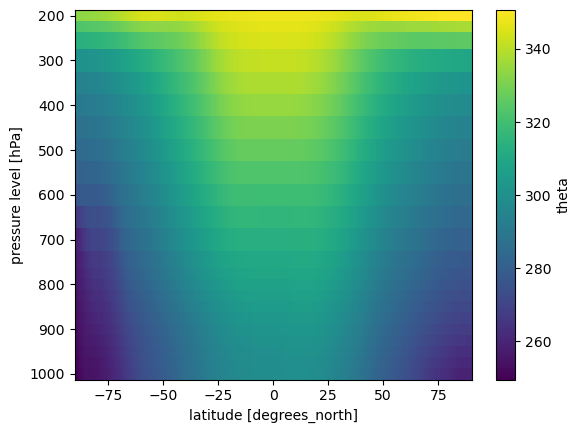

In [28]:
theta_bar.sel(level=slice(200, 1000)).plot(yincrease=False)

d/dp 

In [29]:
# get levels
pressure = theta_bar.level.values  # hPa, shape (37,)

# Compute d(theta_bar)/dp along level dimension (axis=0)
# np.gradient handles uneven spacing correctly using the pressure array
theta_bar_p = np.gradient(theta_bar.values, pressure, axis=0)

theta_bar_p = xr.DataArray(
    theta_bar_p,
    coords=theta_bar.coords,
    dims=theta_bar.dims,
    name='theta_bar_p'
)

theta_bar_p
# Expected dims: (level: 37, latitude: 721)

# Sanity check: values should be NEGATIVE almost everywhere
# since theta increases with altitude (decreases with pressure)
print(f"Min: {float(theta_bar_p.min()):.6f}")
print(f"Max: {float(theta_bar_p.max()):.6f}")
print(f"Any positive values: {bool((theta_bar_p > 0).any())}")

Min: -394.764091
Max: -0.006323
Any positive values: False


In [30]:
pressure

array([   1.,    2.,    3.,    5.,    7.,   10.,   20.,   30.,   50.,
         70.,  100.,  125.,  150.,  175.,  200.,  225.,  250.,  300.,
        350.,  400.,  450.,  500.,  550.,  600.,  650.,  700.,  750.,
        775.,  800.,  825.,  850.,  875.,  900.,  925.,  950.,  975.,
       1000.])

In [31]:
theta_bar_p

<xarray.DataArray 'theta_bar_p' (level: 37, latitude: 721)> Size: 213kB
array([[-3.82667427e+02, -3.82662127e+02, -3.82656891e+02, ...,
        -3.94759617e+02, -3.94764091e+02, -3.94762701e+02],
       [-2.91523177e+02, -2.91520069e+02, -2.91518217e+02, ...,
        -3.00303167e+02, -3.00304693e+02, -3.00303244e+02],
       [-1.70539269e+02, -1.70538355e+02, -1.70539526e+02, ...,
        -1.75905369e+02, -1.75904288e+02, -1.75903007e+02],
       ...,
       [-8.94066678e-02, -8.93090891e-02, -8.92632045e-02, ...,
        -2.52764020e-02, -2.52567899e-02, -2.55243251e-02],
       [-7.72773148e-02, -7.72192291e-02, -7.70970847e-02, ...,
        -2.44988190e-02, -2.45909461e-02, -2.50240468e-02],
       [-6.73341225e-02, -6.73075105e-02, -6.71960014e-02, ...,
        -2.41943080e-02, -2.42213212e-02, -2.45072941e-02]])
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03

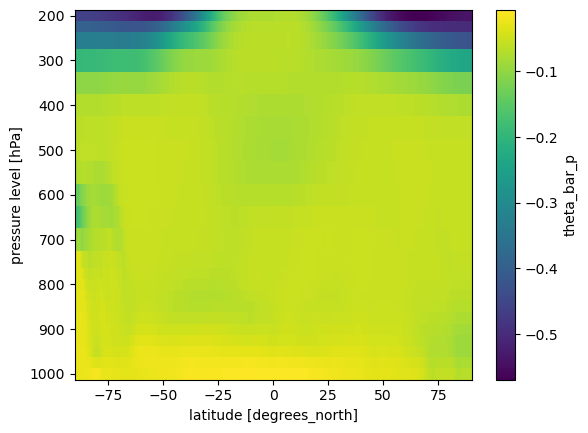

In [32]:
theta_bar_p.sel(level=slice(200, 1000)).plot(yincrease=False)

## Now we get [$v'\theta'$]

In [23]:
# testing things 
vptp2005 = xr.open_mfdataset(f'{WORK}/tam/zonal_means/vptp_zonal_means/zm_meridheatflux2005.nc')

In [24]:
vptp2005.vptp

<xarray.DataArray 'vptp' (level: 37, time: 365, latitude: 721)> Size: 39MB
dask.array<open_dataset-vptp, shape=(37, 365, 721), dtype=float32, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

In [33]:
vt_files = sorted(glob.glob(f'{WORK}/tam/zonal_means/vptp_zonal_means/zm_meridheatflux*.nc'))
vT_zm = xr.open_mfdataset(vt_files, combine='by_coords')['vptp']

vT_zm

<xarray.DataArray 'vptp' (level: 37, time: 16436, latitude: 721)> Size: 2GB
dask.array<concatenate, shape=(37, 16436, 721), dtype=float32, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

In [34]:
# Convert [v'T'] to [v'theta'] using same (p0/p)^kappa factor as Step 1
# xarray broadcasts level coordinate automatically
vtheta_zm = vT_zm * (p0 / vT_zm.level) ** kappa
vtheta_zm.name = 'vtheta'


In [35]:
# Sanity check: units
# [v'T'] has units of K*m/s
# (p0/p)^kappa is dimensionless
# Therefore [v'theta'] has units of K*m/s -- same as [v'T'] ✓
print(f"[v'theta'] min: {float(vtheta_zm.min()):.4f}")
print(f"[v'theta'] max: {float(vtheta_zm.max()):.4f}")

[v'theta'] min: -4993.4641
[v'theta'] max: 11334.0076


In [36]:
print(f"[v'T'] min: {float(vT_zm.min()):.4f}")
print(f"[v'T'] max: {float(vT_zm.max()):.4f}")

[v'T'] min: -814.1686
[v'T'] max: 1705.4364


In [37]:
vtheta_zm

<xarray.DataArray 'vtheta' (level: 37, time: 16436, latitude: 721)> Size: 4GB
dask.array<mul, shape=(37, 16436, 721), dtype=float64, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

In [38]:
# Compute eddy term: [v'theta'] / [theta_bar]_p
# theta_bar_p broadcasts across time dimension automatically
eddy = vtheta_zm/theta_bar_p

eddy.name = 'eddy'


# Sanity checks
print(f"eddy min: {float(eddy.min()):.4f}")
print(f"eddy max: {float(eddy.max()):.4f}")
print(f"Any NaNs: {bool(eddy.isnull().any())}")

eddy min: -1795.1248
eddy max: 4396.6244
Any NaNs: False


In [39]:
eddy

<xarray.DataArray 'eddy' (level: 37, time: 16436, latitude: 721)> Size: 4GB
dask.array<truediv, shape=(37, 16436, 721), dtype=float64, chunksize=(37, 366, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

In [44]:
r0 = 6.371e6  # Earth radius in meters

# Convert latitude to radians --> still descending (90 to -89.75)
lat_rad = np.deg2rad(eddy.latitude.values)  # shape (721,)

# Compute d(eddy)/dphi along latitude axis
deddy_dphi = np.gradient(eddy.values, lat_rad, axis=2)

# Correct for descending latitude direction bc np.gradient 
"""
THIS IS WRONG. THE NEGATION IS NOT NEEDED (FOR FUTURE REFERENCE)
"""
#deddy_dphi = -deddy_dphi

# Apply the 1/r0 factor
weddy1_values = deddy_dphi / r0

weddy1 = xr.DataArray(
    weddy1_values,
    coords=eddy.coords,
    dims=eddy.dims,
    name='weddy1'
)

# Expected dims: (level: 37, time: 16436, latitude: 721)
print(f"weddy1 min: {float(weddy1.min()):.6f}")
print(f"weddy1 max: {float(weddy1.max()):.6f}")
print(f"Any NaNs: {bool(weddy1.isnull().any())}")

weddy1 min: -0.014393
weddy1 max: 0.016739
Any NaNs: False


In [55]:
vtheta_zm.level

<xarray.DataArray 'level' (level: 37)> Size: 296B
array([   1.,    2.,    3.,    5.,    7.,   10.,   20.,   30.,   50.,   70.,
        100.,  125.,  150.,  175.,  200.,  225.,  250.,  300.,  350.,  400.,
        450.,  500.,  550.,  600.,  650.,  700.,  750.,  775.,  800.,  825.,
        850.,  875.,  900.,  925.,  950.,  975., 1000.])
Coordinates:
  * level    (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
Attributes:
    long_name:        pressure level
    short_name:       plev
    units:            hPa
    alternate_units:  millibar

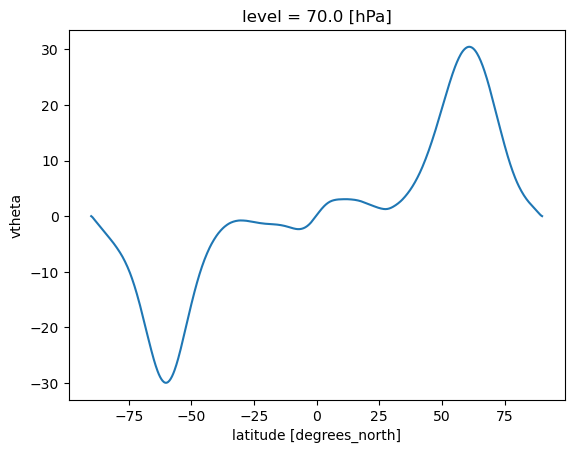

In [56]:
vtheta_zm.mean(dim='time').sel(level=70).plot()

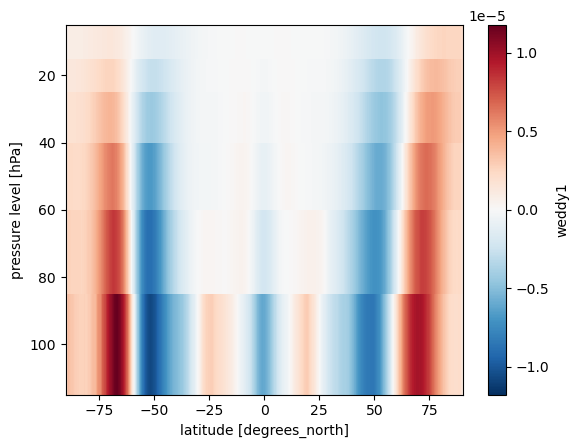

In [50]:
weddy1.mean(dim='time').sel(level=slice(10,100)).plot(yincrease=False)

In [57]:
# Compute tan(phi) from latitude in radians
# Shape (721,) -- xarray broadcasts across level and time automatically
tan_phi = np.tan(np.deg2rad(eddy.latitude.values))

# Wrap into DataArray for clean broadcasting
tan_phi_da = xr.DataArray(
    tan_phi,
    coords={'latitude': eddy.latitude},
    dims=['latitude']
)

# Compute weddy2
weddy2 = -(tan_phi_da / r0) * eddy
weddy2.name = 'weddy2'

# Expected dims: (level: 37, time: 16436, latitude: 721)
print(f"weddy2 min: {float(weddy2.min()):.6f}")
print(f"weddy2 max: {float(weddy2.max()):.6f}")
print(f"Any NaNs: {bool(weddy2.isnull().any())}")

weddy2 min: -0.583489
weddy2 max: 0.643050
Any NaNs: False


In [60]:
weddy2

<xarray.DataArray 'weddy2' (latitude: 721, level: 37, time: 16436)> Size: 4GB
dask.array<multiply, shape=(721, 37, 16436), dtype=float64, chunksize=(721, 37, 366), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31

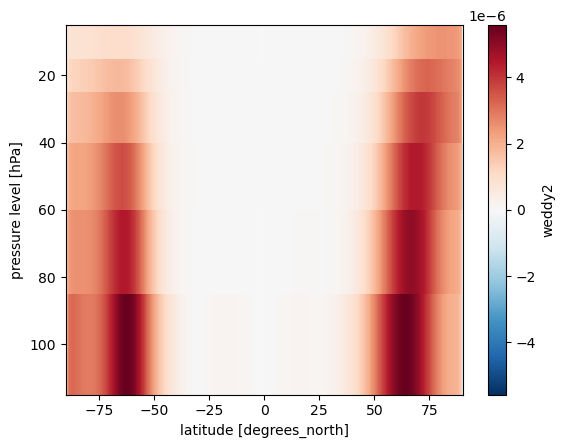

In [62]:
weddy2.transpose('level', 'time', 'latitude').mean(dim='time').sel(level=slice(10,100)).plot(yincrease=False)

In [63]:
# Load and concatenate unfiltered zonal mean w
w_files = sorted(glob.glob(f'{WORK}/tam/zonal_means/W_zonal_means/zmWdaily*.nc'))
w_zm = xr.open_mfdataset(w_files, combine='by_coords')['W']

# Convert weddy1 and weddy2 from hPa/s to Pa/s (* 100)
# Then assemble w*
wstar = w_zm + (weddy1 + weddy2) * 100

wstar.name = 'w*'

# Expected dims: (level: 37, time: 16436, latitude: 721)
print(f"wstar min: {float(wstar.min()):.6f}")
print(f"wstar max: {float(wstar.max()):.6f}")
print(f"Any NaNs: {bool(wstar.isnull().any())}")

wstar min: -58.262342
wstar max: 64.271561
Any NaNs: False


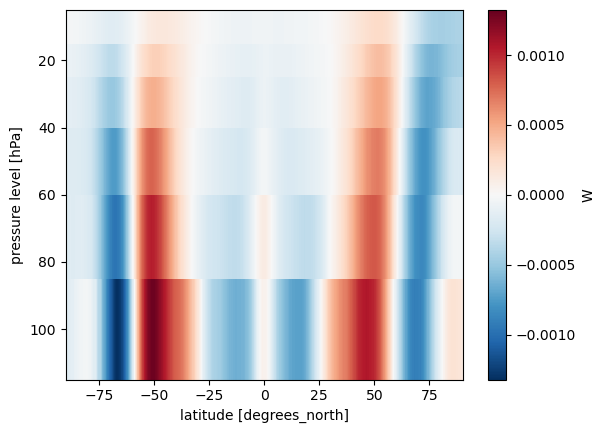

In [64]:
w_zm.mean(dim='time').sel(level=slice(10,100)).plot(yincrease=False)

In [47]:
w_zm.max().values

array(0.559029, dtype=float32)

In [48]:
w_zm.min().values

array(-0.7258116, dtype=float32)

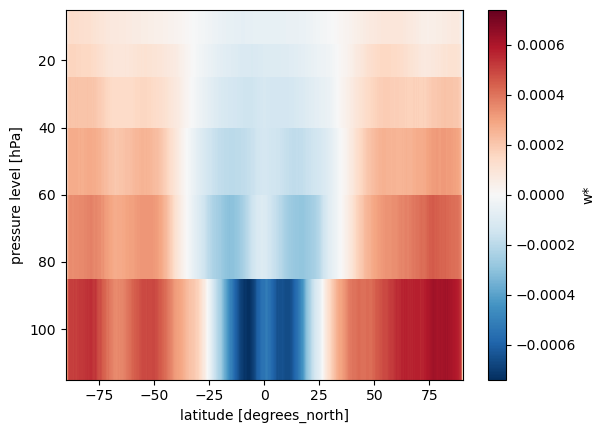

In [69]:
wstar.mean(dim='time').sel(level=slice(10,100)).plot(yincrease=False)

In [66]:
import os

output_dir = f'{WORK}/tam/zonal_means/wstar_zonal_means'
os.makedirs(output_dir, exist_ok=True)

years = np.arange(1979, 2024)

for year in years:
    print(f"Saving {year}...")
    wstar_year = wstar.sel(time=str(year))
    wstar_year.to_netcdf(os.path.join(output_dir, f'zmwstardaily{year}.nc'))

print("Done!")

Saving 1979...
Saving 1980...
Saving 1981...
Saving 1982...
Saving 1983...
Saving 1984...
Saving 1985...
Saving 1986...
Saving 1987...
Saving 1988...
Saving 1989...
Saving 1990...
Saving 1991...
Saving 1992...
Saving 1993...
Saving 1994...
Saving 1995...
Saving 1996...
Saving 1997...
Saving 1998...
Saving 1999...
Saving 2000...
Saving 2001...
Saving 2002...
Saving 2003...
Saving 2004...
Saving 2005...
Saving 2006...
Saving 2007...
Saving 2008...
Saving 2009...
Saving 2010...
Saving 2011...
Saving 2012...
Saving 2013...
Saving 2014...
Saving 2015...
Saving 2016...
Saving 2017...
Saving 2018...
Saving 2019...
Saving 2020...
Saving 2021...
Saving 2022...
Saving 2023...
Done!


In [67]:
filepath = f'{WORK}/tam/zonal_means/wstar_zonal_means'

In [68]:
zmwstaranncyc = uf.annual_cycle(f'{filepath}', 'zmwstardaily', 'w*',  1979, 2023)

Year 1979: original shape = (37, 365, 721)
Year 1980: original shape = (37, 366, 721)
1980 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1981: original shape = (37, 365, 721)
Year 1982: original shape = (37, 365, 721)
Year 1983: original shape = (37, 365, 721)
Year 1984: original shape = (37, 366, 721)
1984 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 1985: original shape = (37, 365, 721)
Year 1986: original shape = (37, 365, 721)
Year 1987: original shape = (37, 365, 721)
Year 1988: original shape = (37, 366, 721)
1988 is a leap year or does not have 365 time coordinates!


...

Year 2013: original shape = (37, 365, 721)
Year 2014: original shape = (37, 365, 721)
Year 2015: original shape = (37, 365, 721)
Year 2016: original shape = (37, 366, 721)
2016 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2017: original shape = (37, 365, 721)
Year 2018: original shape = (37, 365, 721)
Year 2019: original shape = (37, 365, 721)
Year 2020: original shape = (37, 366, 721)
2020 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Year 2021: original shape = (37, 365, 721)
Year 2022: original shape = (37, 365, 721)
Year 2023: original shape = (37, 365, 721)


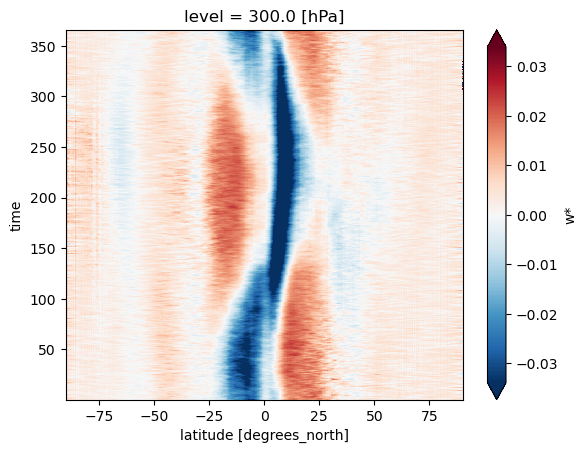

In [71]:
zmwstaranncyc.sel(level=300).plot(robust=True)

In [73]:
zmwstaranncyc.to_netcdf(f'{WORK}/tam/annual_cycles/zmwstardaily_annual_cycle.nc')

In [74]:
zmWanncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/zmWdaily_annual_cycle.nc')

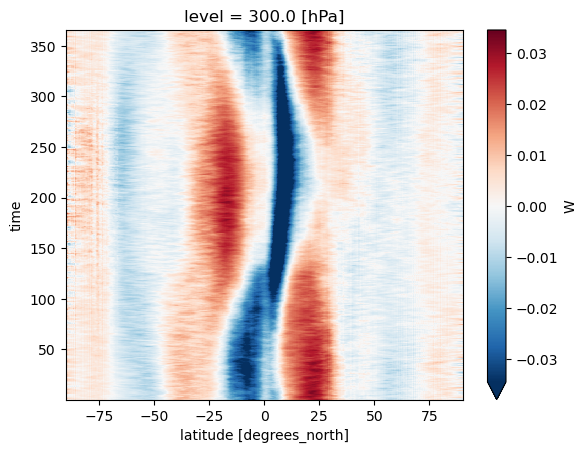

In [75]:
zmWanncyc.W.sel(level=300).plot(robust=True)

In [76]:
wstaranncyc = xr.open_mfdataset(f'{WORK}/tam/annual_cycles/zmwstardaily_annual_cycle.nc')

In [77]:
for year in range(1979, 2024):
    wstaranomalies = uf.calcanomaly(wstaranncyc ,f'{WORK}/tam/zonal_means/wstar_zonal_means/zmwstardaily{year}.nc', 'w*')
    wstaranomalies.to_netcdf(f'{WORK}/tam/anoms/zmwstar_anomalies/zmwstardailyanom{year}.nc')
    print(f'Daily zonal mean anomaly completed for {year}')
    print(f"NaNs: {np.isnan(wstaranomalies.values).sum()}")
    print(f"NaN fraction: {np.isnan(wstaranomalies.values).mean():.4f}")

Daily zonal mean anomaly completed for 1979
NaNs: 0
NaN fraction: 0.0000
1980 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Daily zonal mean anomaly completed for 1980
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1981
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1982
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1983
NaNs: 0
NaN fraction: 0.0000
1984 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Daily zonal mean anomaly completed for 1984
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1985
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1986
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 1987
NaNs: 0
NaN fraction: 0.0000
1988 is a leap year or does not have 365 time coordinates!


...

Daily zonal mean anomaly completed for 2012
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2013
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2014
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2015
NaNs: 0
NaN fraction: 0.0000
2016 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Daily zonal mean anomaly completed for 2016
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2017
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2018
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2019
NaNs: 0
NaN fraction: 0.0000
2020 is a leap year or does not have 365 time coordinates!


/glade/u/home/leonardgu/tam/notebooks/usefulfunc.py:47: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  interp = xr.apply_ufunc(


Daily zonal mean anomaly completed for 2020
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2021
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2022
NaNs: 0
NaN fraction: 0.0000
Daily zonal mean anomaly completed for 2023
NaNs: 0
NaN fraction: 0.0000


In [78]:
zmwstardanom1979_2023 = uf.stackanoms('zmwstar', 'w*')

In [79]:
zmwstardanom1979_2023

<xarray.DataArray 'w*' (year: 45, level: 37, latitude: 721, time: 365)> Size: 4GB
dask.array<concatenate, shape=(45, 37, 721, 365), dtype=float64, chunksize=(1, 37, 721, 365), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * year      (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023

In [80]:
zmwstardanom1979_2023.to_netcdf(f'{WORK}/tam/full_anoms/zmwstardanoms1979_2023.nc')

In [20]:
zmwstardanoms79_23 = xr.open_mfdataset(f'{WORK}/tam/full_anoms/zmwstardanoms1979_2023.nc')

In [21]:
zmwstardanomts = zmwstardanoms79_23['w*'].stack(alltime = ('year', 'time'))

In [22]:
zmwstardanomts

<xarray.DataArray 'w*' (level: 37, latitude: 721, alltime: 16425)> Size: 4GB
dask.array<reshape, shape=(37, 721, 16425), dtype=float64, chunksize=(37, 721, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * alltime   (alltime) object 131kB MultiIndex
  * year      (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [23]:
highpzmwstara, lowpzmwstara = uf.butter1yhighp(zmwstardanomts, 4)

In [24]:
edge_trim = 183

highpwstarshaved = highpzmwstara.isel(alltime=slice(edge_trim, -edge_trim))

In [25]:
highpwstarshaved

<xarray.DataArray (level: 37, latitude: 721, alltime: 16059)> Size: 3GB
array([[[-3.21877145e-05, -2.79391968e-05,  4.35495591e-05, ...,
          2.91067448e-05,  2.65158916e-05, -3.35234231e-05],
        [-1.97404762e-05, -2.16078312e-05,  4.25017752e-05, ...,
          4.94735425e-05,  3.55546000e-05, -1.92314097e-05],
        [-1.99083857e-05, -2.11740373e-05,  4.32654424e-05, ...,
          4.68502452e-05,  3.27522358e-05, -1.63262254e-05],
        ...,
        [ 1.00713406e-05, -2.88642805e-05, -4.89399284e-05, ...,
         -3.62144317e-06, -1.91727002e-06, -1.24241308e-04],
        [ 1.31286333e-05, -2.54196565e-05, -4.99246096e-05, ...,
         -2.09498129e-06, -2.66813034e-06, -1.28654215e-04],
        [ 1.30657997e-05,  1.66616410e-05,  8.22178057e-05, ...,
          9.49654925e-05,  6.23723972e-05, -4.85339675e-06]],

       [[-2.71802240e-05,  2.45302285e-05, -6.04102137e-05, ...,
          1.08778760e-04, -4.88590259e-05,  6.44339749e-05],
        [ 5.11742891e-06,  4.87653256e-05, -3.91612650e-05, ...,
          1.16407777e-04, -3.69690355e-05,  7.81114816e-05],
        [ 2.59222924e-06,  5.04945696e-05, -3.03937441e-05, ...,
          1.03967879e-04, -4.05925061e-05,  7.71605950e-05],
...
        [ 1.65617107e-01, -2.72592488e-01, -2.13799536e-01, ...,
         -2.14521385e-01,  7.38521613e-02,  3.43809176e-01],
        [ 3.55839787e-01, -3.14627063e-01, -2.61805896e-01, ...,
         -3.45567493e-01, -3.95088698e-02,  3.62403393e-01],
        [ 2.11962376e-01, -1.65563299e-01, -1.47989326e-01, ...,
         -1.57769865e-01,  1.67882985e-02,  2.46059608e-01]],

       [[-1.20649258e-02,  8.08312238e-03, -9.88824149e-03, ...,
          2.25689837e-03, -6.96469798e-03,  2.71846818e-02],
        [-7.35486150e-03,  1.14881452e-02, -5.45880151e-03, ...,
         -2.28133017e-02, -2.76982814e-02,  1.04206979e-02],
        [-5.71755215e-03,  1.72112198e-02, -1.27770965e-03, ...,
         -2.09168354e-02, -2.73796806e-02,  4.93272289e-03],
        ...,
        [ 1.68527946e-01, -2.75732784e-01, -2.15280362e-01, ...,
         -2.10694846e-01,  6.15945494e-02,  3.53661798e-01],
        [ 3.59643335e-01, -3.18035534e-01, -2.66063800e-01, ...,
         -3.59313418e-01, -2.38513177e-02,  3.58036026e-01],
        [ 2.14297090e-01, -1.67367828e-01, -1.51002896e-01, ...,
         -1.52371140e-01,  5.49801312e-02,  2.58829086e-01]]])
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * alltime   (alltime) object 128kB MultiIndex
  * year      (alltime) int64 128kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 128kB 184 185 186 187 188 ... 178 179 180 181 182

In [27]:
wstar300 =   highpwstarshaved.sel(level=300)
wstar300corr = uf.lat_lag_corr(tam,wstar300)

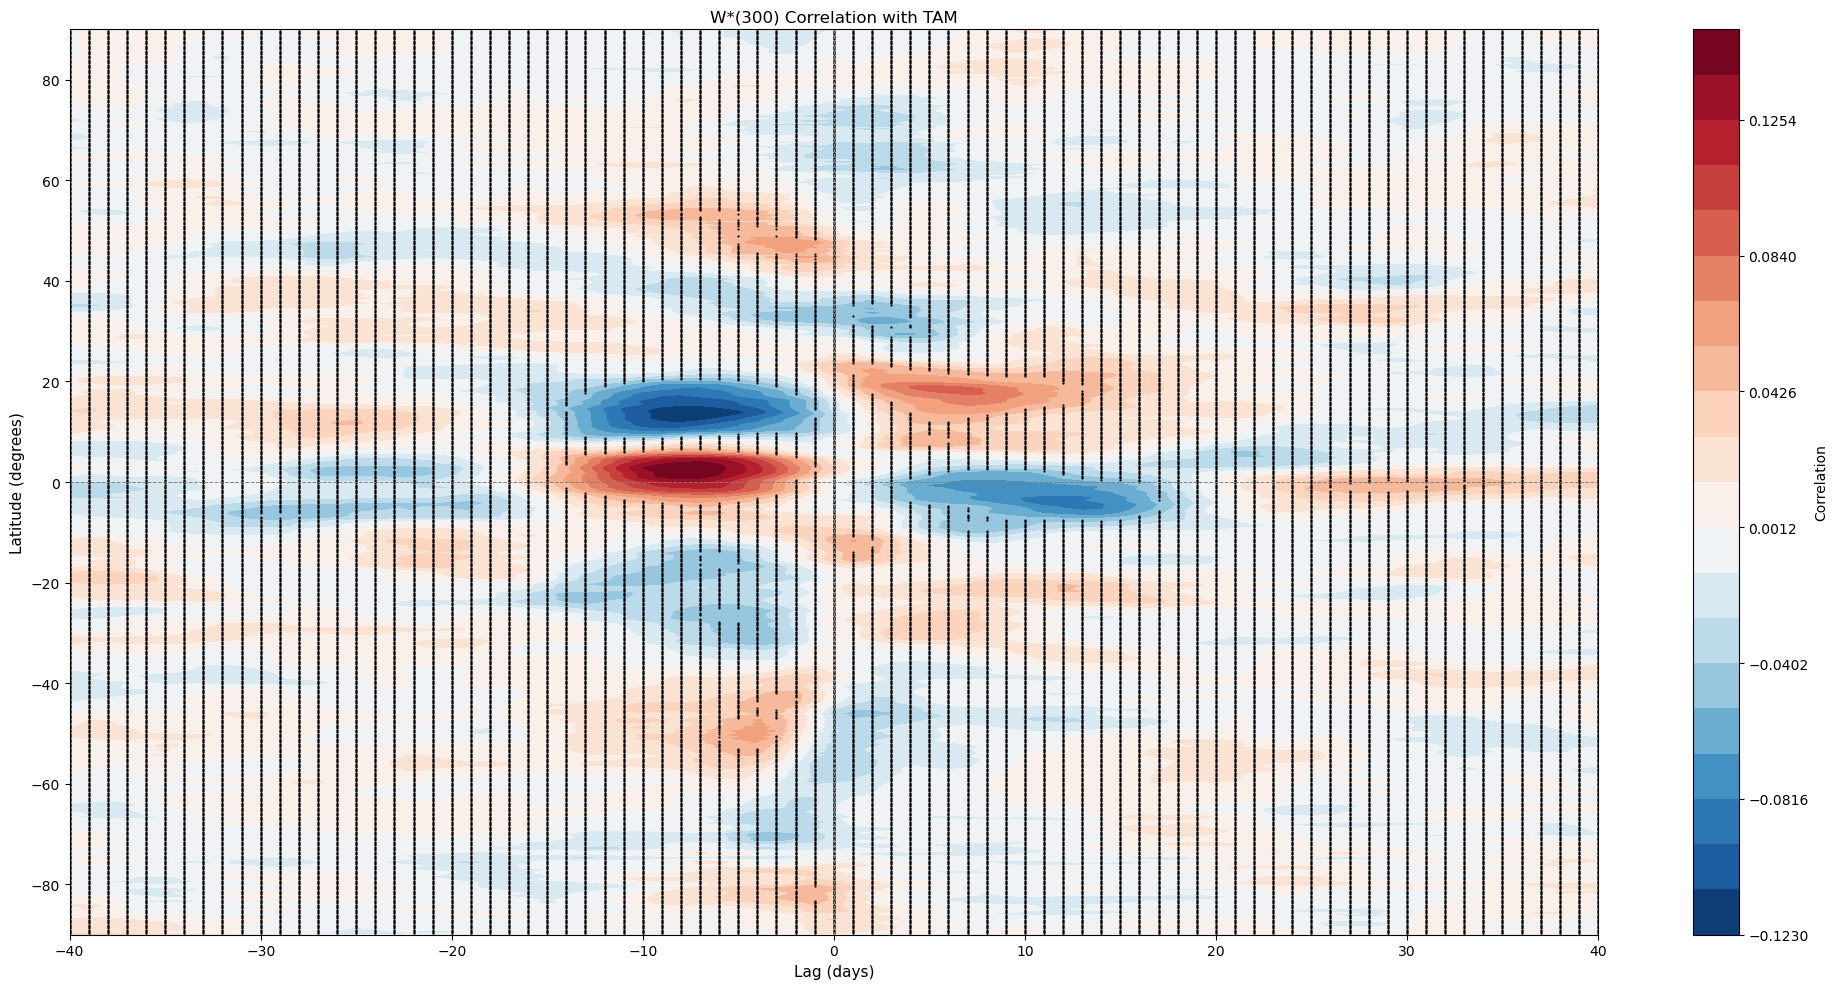

In [88]:
fig, ax = plt.subplots(figsize=(20, 10))
cf = uf.plot_corr_with_significance(
    ax, wstar300corr, tau=10,
    vmin=float(wstar300corr.min()), vmax=float(wstar300corr.max()),
    ylabel='Latitude (degrees)'
)
ax.set_title('W*(300) Correlation with TAM')
fig.colorbar(cf, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

In [89]:
djf_tam_chunks, djf_wstar300_chunks, jja_tam_chunks, jja_wstar300_chunks=djf_jja(tam, wstar300, 40)

djfwstar300_corr = seasonal_lag_corr(djf_tam_chunks, djf_wstar300_chunks)
jjawstar300_corr = seasonal_lag_corr(jja_tam_chunks, jja_wstar300_chunks)

DJF years collected: 44
JJA years collected: 43


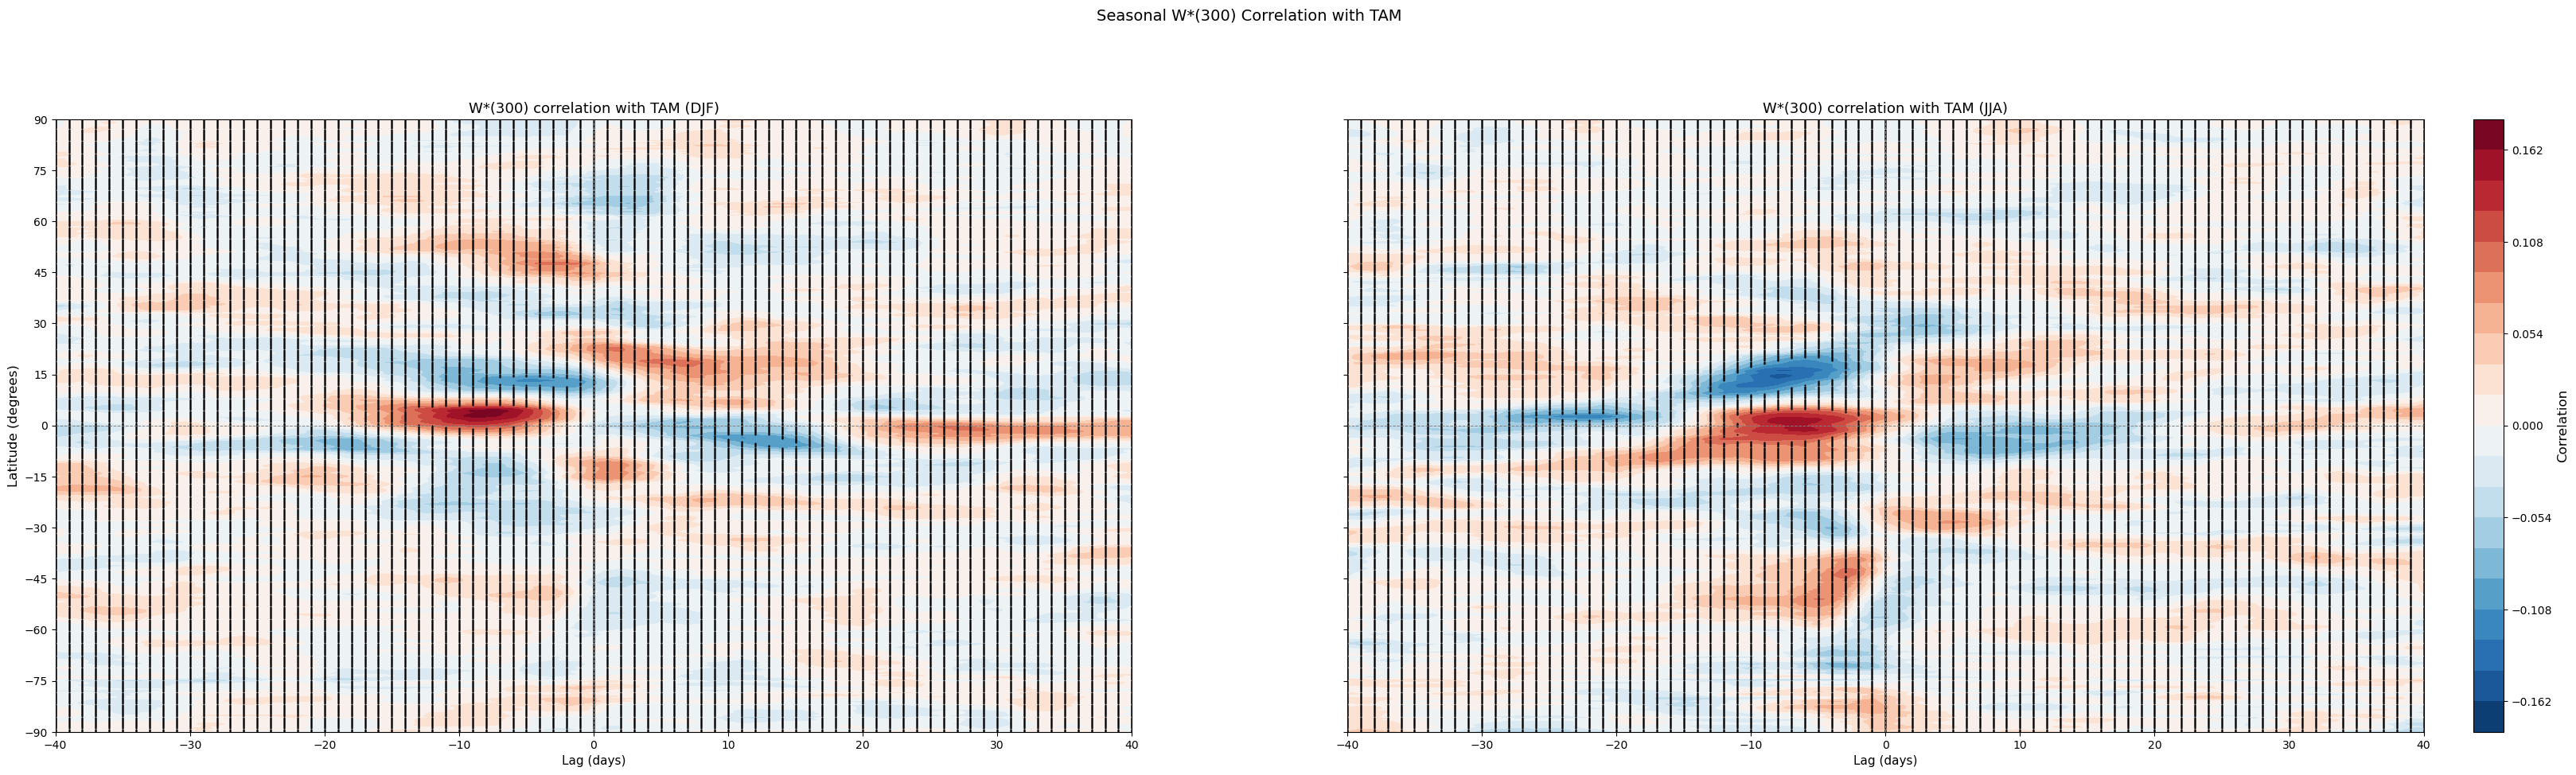

In [90]:
latlag_plot_seasonal_corr(djfwstar300_corr, jjawstar300_corr, varname = 'W*(300)', vmin=-0.18, vmax=0.18, tau=10)

DJF years collected: 44
JJA years collected: 43
MAM years collected: 43
SON years collected: 43


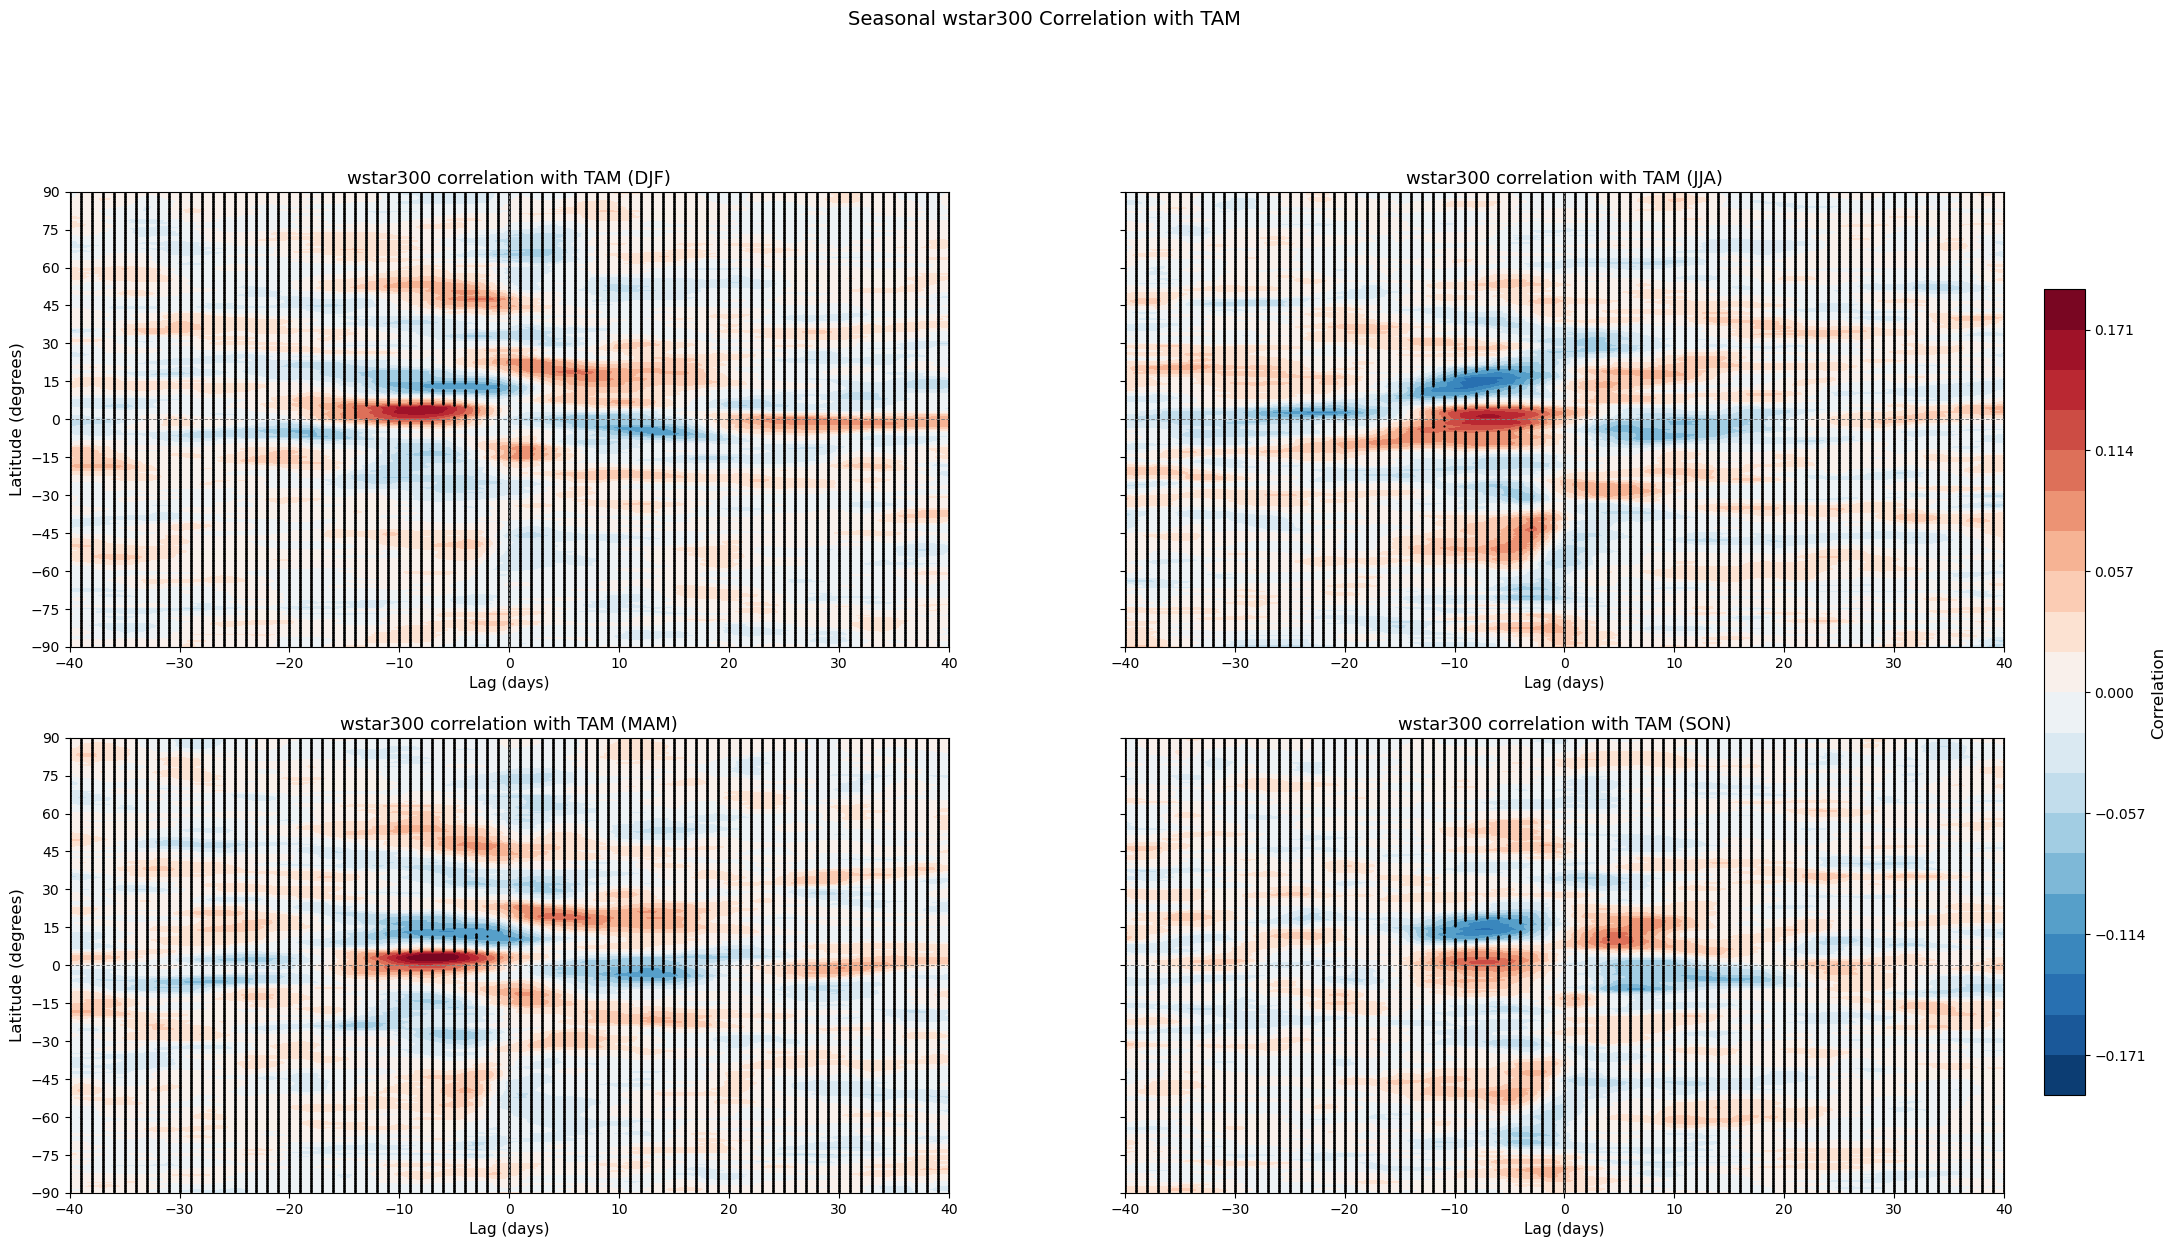

In [28]:
djf_tam_chunks, djf_wstar300_chunks, jja_tam_chunks, jja_wstar300_chunks, mam_tam_chunks, mam_wstar300_chunks, son_tam_chunks, son_wstar300_chunks = djf_jja_mam_son(tam, wstar300, 40)

djfwstar300_corr = seasonal_lag_corr(djf_tam_chunks, djf_wstar300_chunks)
jjawstar300_corr = seasonal_lag_corr(jja_tam_chunks, jja_wstar300_chunks)
mamwstar300_corr = seasonal_lag_corr(mam_tam_chunks, mam_wstar300_chunks)
sonwstar300_corr = seasonal_lag_corr(son_tam_chunks, son_wstar300_chunks)

latlag_plot_fullseasonal_corr(
    djfwstar300_corr, jjawstar300_corr, mamwstar300_corr, sonwstar300_corr,
    varname='wstar300',
    vmin=-0.19, vmax=0.19,
    tau=10,
)

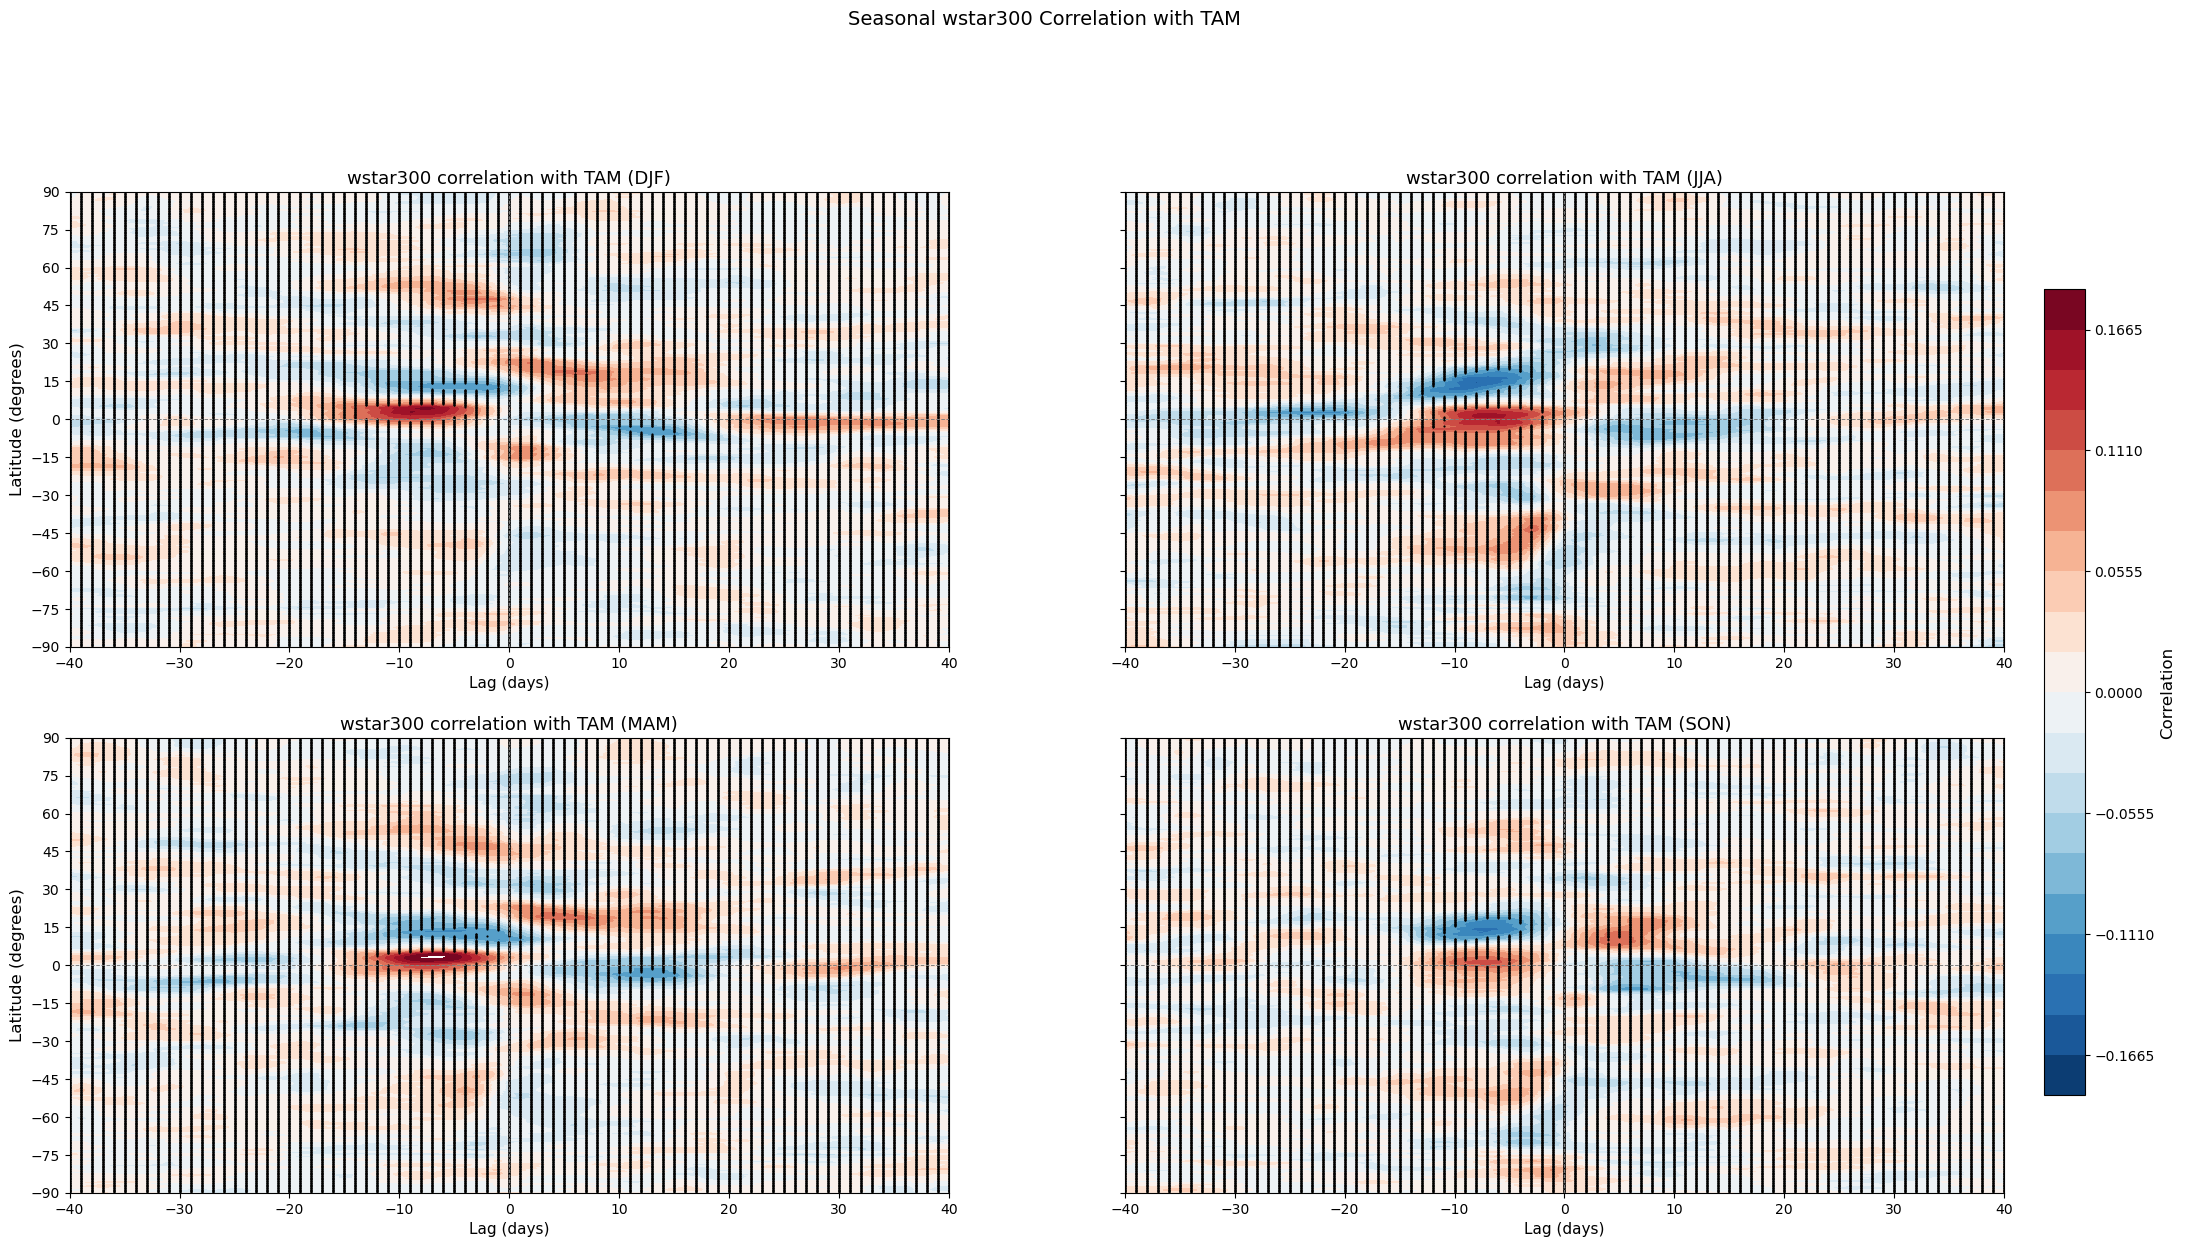

In [29]:
latlag_plot_fullseasonal_corr(
    djfwstar300_corr, jjawstar300_corr, mamwstar300_corr, sonwstar300_corr,
    varname='wstar300',
    vmin=-0.185, vmax=0.185,
    tau=10,
)